<a href="https://colab.research.google.com/github/RagaSandhiya05/LLM-From-Scratch/blob/main/11_Training_Loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**STACKING TRANSFORMER BLOCKS AND TRAINING LOOP**

**Import Libraries**

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(42)
print("PyTorch Version : " , torch.__version__)

PyTorch Version :  2.11.0+cpu


**Sample DataSet**

In [2]:
sentences = [
    "I love Python" ,
    "Python is powerful" ,
    "Machine learning is fun" ,
    "Artificial Intelligence is amazing"
]

print("Training Sentences :\n")
for sentence in sentences :
  print(sentence)

Training Sentences :

I love Python
Python is powerful
Machine learning is fun
Artificial Intelligence is amazing


**Build Vocabulary**

In [3]:
words = []
for sentence in sentences :
  words.extend(sentence.lower().split())
vocab = sorted(set(words))
word_to_id = {word : idx for idx , word in enumerate(vocab)}
id_to_word = {idx : word for word , idx in word_to_id.items()}

print(word_to_id)

{'amazing': 0, 'artificial': 1, 'fun': 2, 'i': 3, 'intelligence': 4, 'is': 5, 'learning': 6, 'love': 7, 'machine': 8, 'powerful': 9, 'python': 10}


**Create Training Data**

In [4]:
X = []
Y = []
for sentence in sentences :
  tokens = sentence.lower().split()
  for i in range(len(tokens) - 1) :
    X.append(word_to_id[tokens[i]])
    Y.append(word_to_id[tokens[i + 1]])
X = torch.tensor(X)
Y = torch.tensor(Y)
print("Input IDs : " , X)
print("Target IDs : " , Y)

Input IDs :  tensor([ 3,  7, 10,  5,  8,  6,  5,  1,  4,  5])
Target IDs :  tensor([ 7, 10,  5,  9,  6,  5,  2,  4,  5,  0])


**Define Transformer Block**

In [6]:
class TransformerBlock(nn.Module) :
    def __init__(self, embedding_dim) :
        super().__init__()
        self.ffn = nn.Sequential(
            nn.Linear(embedding_dim , embedding_dim * 2) ,
            nn.ReLU() ,
            nn.Linear(embedding_dim * 2 , embedding_dim)
        )
        self.norm = nn.LayerNorm(embedding_dim)
    def forward(self , x) :
        out = self.ffn(x)
        x = self.norm(x + out)

        return x

**Build Mini Transformer**

In [7]:
class MiniTransformer(nn.Module) :
    def __init__(self , vocab_size , embedding_dim , num_blocks) :
        super().__init__()
        self.embedding = nn.Embedding(vocab_size , embedding_dim)
        self.blocks = nn.Sequential(
            *[TransformerBlock(embedding_dim) for _ in range(num_blocks)]
        )
        self.output = nn.Linear(embedding_dim , vocab_size)
    def forward(self, x) :
        x = self.embedding(x)
        x = self.blocks(x)
        x = self.output(x)

        return x

**Create Model**

In [8]:
embedding_dim = 16
num_blocks = 2
model = MiniTransformer(
    len(vocab) ,
    embedding_dim ,
    num_blocks
)
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters() , lr = 0.01)

print(model)

MiniTransformer(
  (embedding): Embedding(11, 16)
  (blocks): Sequential(
    (0): TransformerBlock(
      (ffn): Sequential(
        (0): Linear(in_features=16, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=16, bias=True)
      )
      (norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    )
    (1): TransformerBlock(
      (ffn): Sequential(
        (0): Linear(in_features=16, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=16, bias=True)
      )
      (norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    )
  )
  (output): Linear(in_features=16, out_features=11, bias=True)
)


**Training Loop**

In [9]:
epochs = 200
loss_history = []
for epoch in range(epochs) :
    optimizer.zero_grad()
    predictions = model(X)
    loss = loss_function(predictions , Y)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if epoch % 20 == 0 :
        print(f"Epoch {epoch:3d} | Loss = {loss.item():.4f}")

Epoch   0 | Loss = 2.6151
Epoch  20 | Loss = 0.4168
Epoch  40 | Loss = 0.3399
Epoch  60 | Loss = 0.3341
Epoch  80 | Loss = 0.3327
Epoch 100 | Loss = 0.3320
Epoch 120 | Loss = 0.3315
Epoch 140 | Loss = 0.3312
Epoch 160 | Loss = 0.3309
Epoch 180 | Loss = 0.3307


**Predict Next Word**

In [11]:
def predict_next_word(word) :
    word = word.lower()
    if word not in word_to_id :
        print("Word not found.")
        return
    x = torch.tensor([word_to_id[word]])
    model.eval()
    with torch.no_grad() :
        output = model(x)
        prediction = torch.argmax(output , dim = 1).item()

    print("Input :" , word)

    print("Prediction :" , id_to_word[prediction])

**Test Model**

In [12]:
predict_next_word("python")

predict_next_word("machine")

predict_next_word("artificial")

predict_next_word("love")

Input : python
Prediction : is
Input : machine
Prediction : learning
Input : artificial
Prediction : intelligence
Input : love
Prediction : python


**Plot Training Loss**

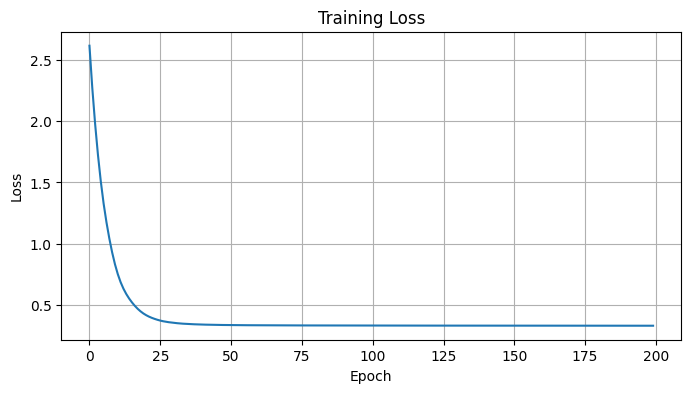

In [13]:
plt.figure(figsize = (8 , 4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

**Model Summary**

In [14]:
print("Vocabulary Size :" , len(vocab))

print("Embedding Dimension :" , embedding_dim)

print("Transformer Blocks :" , num_blocks)

print("Training Samples :" , len(X))

Vocabulary Size : 11
Embedding Dimension : 16
Transformer Blocks : 2
Training Samples : 10
